## 1. Compare Portfolios

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [13]:
t_eval = np.load('data/t_eval.npy', allow_pickle = True)
spy_returns = pd.read_csv('data/spy_returns.csv', index_col = 0, parse_dates = True).reindex(t_eval)
benchmark = (1 + spy_returns.reindex(t_eval)).cumprod()

In [14]:
factor_returns = pd.read_csv('outputs/factor_returns.csv', index_col = 0, parse_dates = True)
ra_returns = pd.read_csv('outputs/ra_returns.csv', index_col = 0, parse_dates = True)
long_returns = pd.read_csv('outputs/long_returns.csv', index_col = 0, parse_dates = True)


factor_portfolio = (1 + factor_returns).cumprod()
ra_portfolio = (1 + ra_returns).cumprod()
long_portfolio = (1 + long_returns).cumprod()


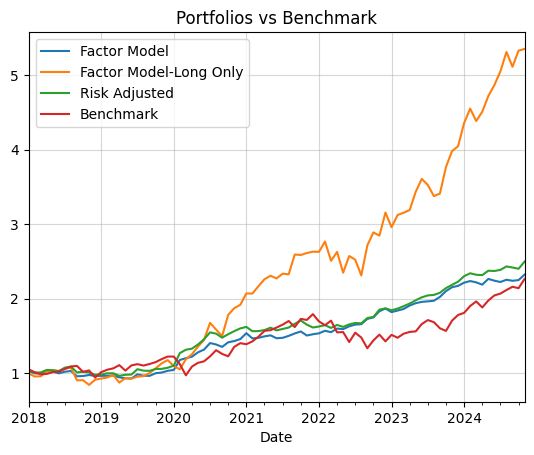

In [15]:
fig, ax = plt.subplots()

factor_portfolio.squeeze().plot(ax=ax, label='Factor Model')
long_portfolio.squeeze().plot(ax=ax, label='Factor Model-Long Only')
ra_portfolio.squeeze().plot(ax=ax, label='Risk Adjusted')
benchmark.squeeze().plot(ax=ax, label='Benchmark')

ax.set_title('Portfolios vs Benchmark')
ax.grid(alpha=0.5)
ax.legend()

plt.savefig("outputs/Portfolios_vs_Benchmark.png")

In [16]:
mvo_returns = np.load('outputs/mvo_returns_lambda.npy', allow_pickle = True).item()
lams = np.arange(1,50,1)

mvo_portfolios = {}
for lam in lams:
    mvo_portfolios[lam] = (1 + mvo_returns[lam]).cumprod()



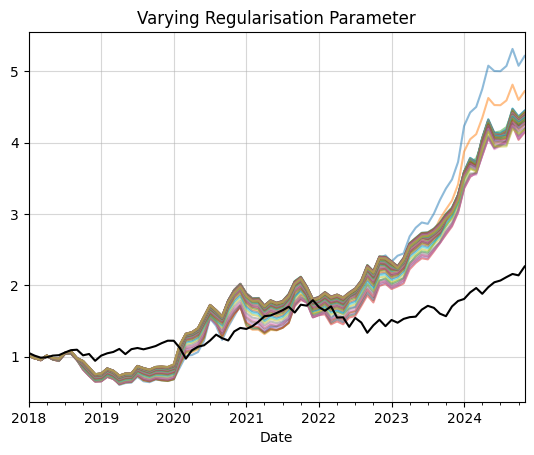

In [17]:
fig, ax = plt.subplots()

for lam in lams:
    mvo_portfolios[lam].plot(ax = ax, alpha = 0.5, label = rf'$\lambda$ = {lam}')

benchmark.squeeze().plot(ax=ax, color = 'black', label='Benchmark')
ax.set_title('Varying Regularisation Parameter')
#ax.legend()
ax.grid(alpha = 0.5)
plt.savefig('outputs/Varying Regularisation Parameter.png')

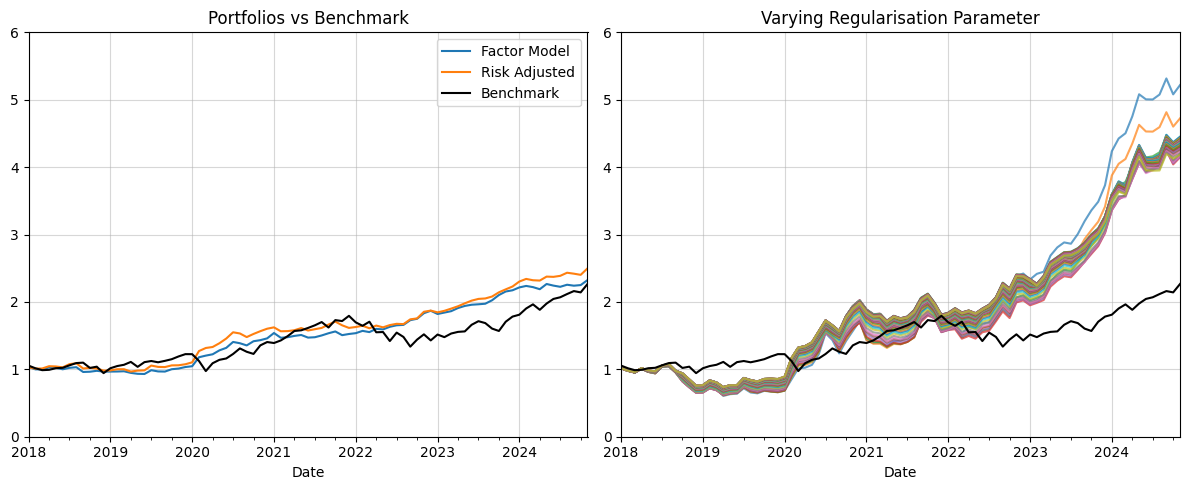

In [18]:
fig, ax = plt.subplots(1,2, figsize = (12,5), sharey = True)

factor_portfolio.squeeze().plot(ax=ax[0], label='Factor Model')
ra_portfolio.squeeze().plot(ax=ax[0], label='Risk Adjusted')

benchmark.squeeze().plot(ax=ax[0], color = 'black', label='Benchmark')

ax[0].set_title('Portfolios vs Benchmark')
ax[0].grid(alpha=0.5)
ax[0].legend()

for lam in lams:
    mvo_portfolios[lam].plot(ax = ax[1], alpha = 0.7, label = rf'$\lambda$ = {lam}')

benchmark.squeeze().plot(ax=ax[1], color = 'black', label='Benchmark')
ax[1].set_title('Varying Regularisation Parameter')
#ax[1].legend()
ax[1].grid(alpha = 0.5)
ax[1].tick_params(axis='y', labelleft=True)
ax[1].set_yticks(ax[0].get_yticks())

plt.tight_layout()
plt.savefig('outputs/portfolios.png')

In [19]:
performance_df = pd.DataFrame(columns = ['Lambda', 'Final Value'])
for lam, portfolio in mvo_portfolios.items():
    performance_df.loc[lam] = [lam, portfolio.iloc[-1]]

performance_df.set_index('Lambda', inplace = True)
performance_df.sort_values('Final Value', ascending = False)

,Final Value
Lambda,
1.0,5.216689
2.0,4.723091
20.0,4.451313
21.0,4.448669
19.0,4.441436
18.0,4.433238
22.0,4.429920
17.0,4.423745
23.0,4.412571


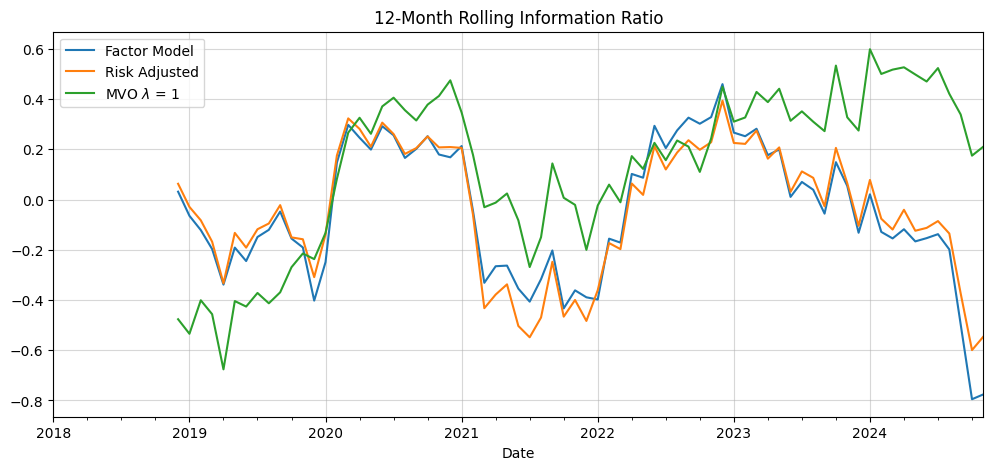

In [20]:
# Rolling IR = rolling excessive returns (mean) / rolling excessive volatility (std)

def rolling_IR(returns, benchmark_returns = spy_returns, window = 12):
    excess_returns = returns.squeeze() - benchmark_returns.squeeze()
    rolling_mean = excess_returns.rolling(window).mean()
    rolling_std = excess_returns.rolling(window).std()
    rolling_ir = rolling_mean / rolling_std
    return rolling_ir

fig, ax = plt.subplots(figsize = (12,5))
rolling_IR((factor_returns), window=12).plot(ax = ax, label = 'Factor Model')
rolling_IR((ra_returns), window=12).plot(ax = ax, label = 'Risk Adjusted')
rolling_IR((mvo_returns[1]), window=12).plot(ax = ax, label = r'MVO $\lambda$ = 1')
ax.set_title('12-Month Rolling Information Ratio')
ax.legend()
ax.grid(alpha = 0.5)


plt.savefig('outputs/rolling_IR.png')


## 2. Portfolio Analytics

In [21]:
def analyse_portfolio(portfolio_returns, outs = False):

    if isinstance(portfolio_returns, pd.Series):
        portfolio_returns = portfolio_returns.to_frame()
        
    mean = portfolio_returns.mean().item()
    std = portfolio_returns.std().item()
    sharpe = np.sqrt(12) * mean / std

    portfolio = (1 + portfolio_returns).cumprod()
    total_return = portfolio.iloc[-1].item() - 1
    annual_return = (1 + total_return) ** (12 / len(portfolio)) - 1
    running_max = portfolio.cummax()
    drawdown = portfolio / running_max - 1
    max_dd = drawdown.min().item()

    if outs:
        return mean, std, sharpe, total_return, annual_return, max_dd
    
    else:
        print(f"Mean Return: {mean * 100:.2f}%")
        print(f"Mean Std: {std * 100:.2f}%")
        print(f"Sharpe Ratio: {sharpe:.2f}")
        print(f"Total Returns: {total_return * 100:.0f}%")
        print(f"Annual Return: {annual_return * 100:.0f}%")
        print(f"Max drawdown: {max_dd * 100:.0f}%")

    


In [22]:
print('factor model')
analyse_portfolio(factor_returns)
print()

print('risk-adjusted model')
analyse_portfolio(ra_returns)
print()

print(rf'mean-variance optimised model ($\lambda = 1$)')
analyse_portfolio(mvo_returns[1])
print()



factor model
Mean Return: 1.06%
Mean Std: 2.67%
Sharpe Ratio: 1.37
Total Returns: 132%
Annual Return: 13%
Max drawdown: -10%

risk-adjusted model
Mean Return: 1.15%
Mean Std: 2.86%
Sharpe Ratio: 1.39
Total Returns: 150%
Annual Return: 14%
Max drawdown: -11%

mean-variance optimised model ($\lambda = 1$)
Mean Return: 2.36%
Mean Std: 8.51%
Sharpe Ratio: 0.96
Total Returns: 422%
Annual Return: 27%
Max drawdown: -43%

